In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 4.4 MB/s eta 0:00:00


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 1 · LOAD THE DATASET
# ══════════════════════════════════════════════════════════════════════════
import os, glob, yaml, shutil, random
from pathlib import Path

# ---- Locate data.yaml (works for /kaggle/input datasets or manual upload) ----
candidates = (glob.glob('/kaggle/input/**/data.yaml', recursive=True) +
              glob.glob('/kaggle/working/**/data.yaml', recursive=True))
assert candidates, 'data.yaml not found - attach the dataset in Kaggle (Add Data) or upload to /kaggle/working'
DATA_YAML = Path(candidates[0])
DATASET_ROOT = DATA_YAML.parent
print(f' Found data.yaml at: {DATA_YAML}')

# ---- Parse it ----
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)
print(' Dataset config:')
for k, v in data_cfg.items():
    print(f'   {k}: {v}')

CLASS_NAMES = data_cfg.get('names', {})
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
NC = data_cfg.get('nc', len(CLASS_NAMES))

# ---- FIX: data.yaml ships with a hard-coded `path: /home/Sterben/unidataset` ----
# Ultralytics prepends `path` to train/val/test, so it looks in a folder that does
# not exist on Kaggle. /kaggle/input is read-only, so write a corrected copy to
# /kaggle/working and train from that one instead.
fixed_cfg = dict(data_cfg)
fixed_cfg['path'] = str(DATASET_ROOT)              # real location of the dataset
for _k in ('train', 'val', 'test'):                # keep splits relative to `path`
    if fixed_cfg.get(_k) and not os.path.isabs(str(fixed_cfg[_k])):
        _p = Path(DATASET_ROOT) / str(fixed_cfg[_k])
        if not _p.exists():                         # fall back to parent-relative layout
            _p = Path(DATASET_ROOT).parent / str(fixed_cfg[_k])
        fixed_cfg[_k] = str(_p)                     # absolute -> unambiguous
    elif _k not in fixed_cfg or not fixed_cfg[_k]:
        fixed_cfg.pop(_k, None)
FIXED_YAML = Path('/kaggle/working/data_fixed.yaml')
with open(FIXED_YAML, 'w') as f:
    yaml.safe_dump(fixed_cfg, f, sort_keys=False)
print(f'🛠️  Wrote corrected config -> {FIXED_YAML}')
for k in ('path', 'train', 'val', 'test'):
    if k in fixed_cfg:
        print(f'   {k}: {fixed_cfg[k]}  (exists={Path(fixed_cfg[k]).exists()})')

# ---- Resolve each split path (yaml paths are relative to the yaml file) ----
def resolve_split(key):
    """Return sorted list of image files for a split, or None."""
    if key not in data_cfg or data_cfg[key] is None:
        return None
    p = Path(str(data_cfg[key]))
    if not p.is_absolute():
        for base in (DATASET_ROOT, DATASET_ROOT.parent):
            cand = base / p
            if cand.exists():
                p = cand
                break
        else:
            return None
    p = p.resolve()
    if not p.exists():
        return None
    exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp')
    files = [f for e in exts for f in p.rglob(e)] if p.is_dir() else [p]
    return sorted(files)

splits = {}
for split in ['train', 'val', 'test']:
    imgs = resolve_split(split)
    splits[split] = imgs
    print(f'   {split:>6}: {len(imgs) if imgs else 0} images')

assert splits['train'], 'No training images resolved - check data.yaml paths'

# Image <-> label helper (handles common images/labels parallel layout)
def label_for(image_path):
    parts = Path(image_path).parts
    for i, part in enumerate(parts):
        if part == 'images':
            cand = Path(*parts[:i], 'labels', *parts[i+1:]).with_suffix('.txt')
            if cand.exists():
                return cand
    return Path(image_path).with_suffix('.txt')

print('\n🚀 Dataset ready for EDA.')

 Found data.yaml at: /kaggle/input/datasets/plantpog/w43453ert/unidataset/data.yaml
 Dataset config:
   path: /home/Sterben/unidataset
   train: images/train
   val: images/val
   test: images/test
   nc: 2
   names: ['in_uniform', 'not_uniform']
🛠️  Wrote corrected config -> /kaggle/working/data_fixed.yaml
   path: /kaggle/input/datasets/plantpog/w43453ert/unidataset  (exists=True)
   train: /kaggle/input/datasets/plantpog/w43453ert/unidataset/images/train  (exists=True)
   val: /kaggle/input/datasets/plantpog/w43453ert/unidataset/images/val  (exists=True)
   test: /kaggle/input/datasets/plantpog/w43453ert/unidataset/images/test  (exists=True)
    train: 379 images
      val: 50 images
     test: 75 images

🚀 Dataset ready for EDA.


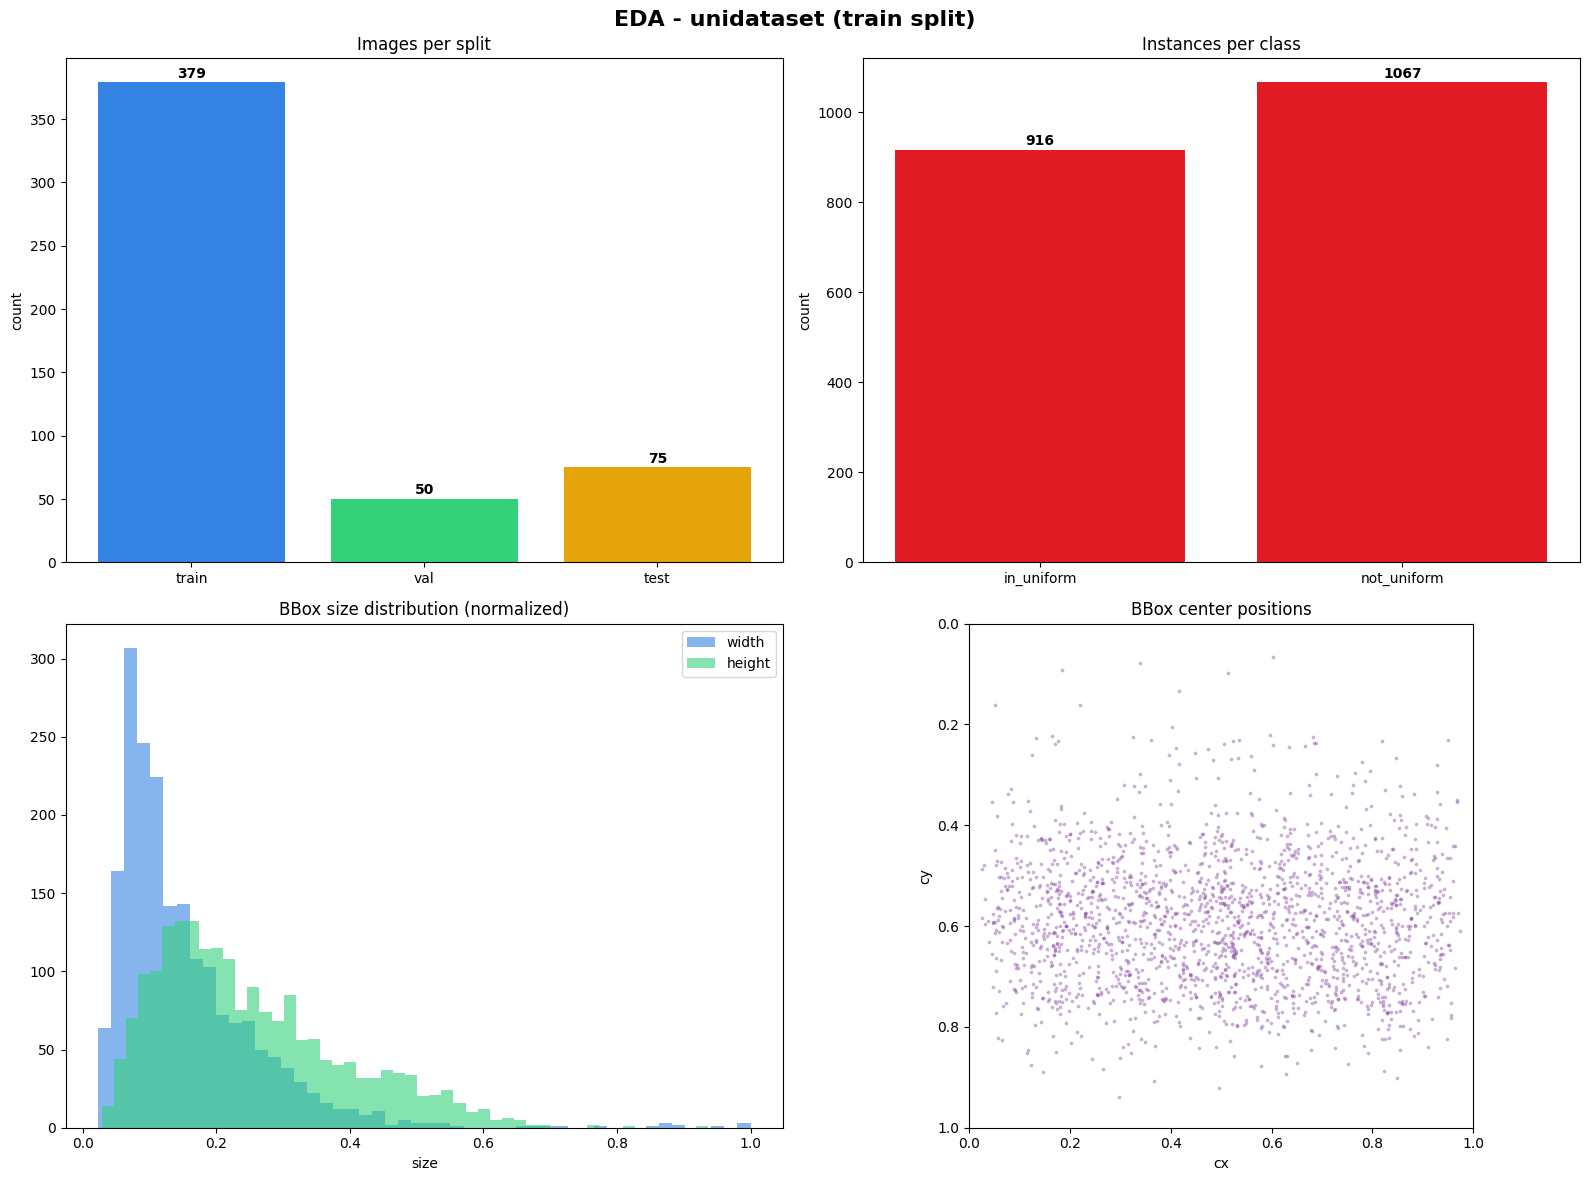

--- Bounding box statistics (normalized) ---
               w          h
count  1983.0000  1983.0000
mean      0.1542     0.2505
std       0.1115     0.1395
min       0.0233     0.0285
25%       0.0800     0.1432
50%       0.1196     0.2183
75%       0.1968     0.3325
max       1.0000     0.9366

Aspect ratio  min=0.15  median=0.59  max=2.27
Class balance ratio max/min = 1.16


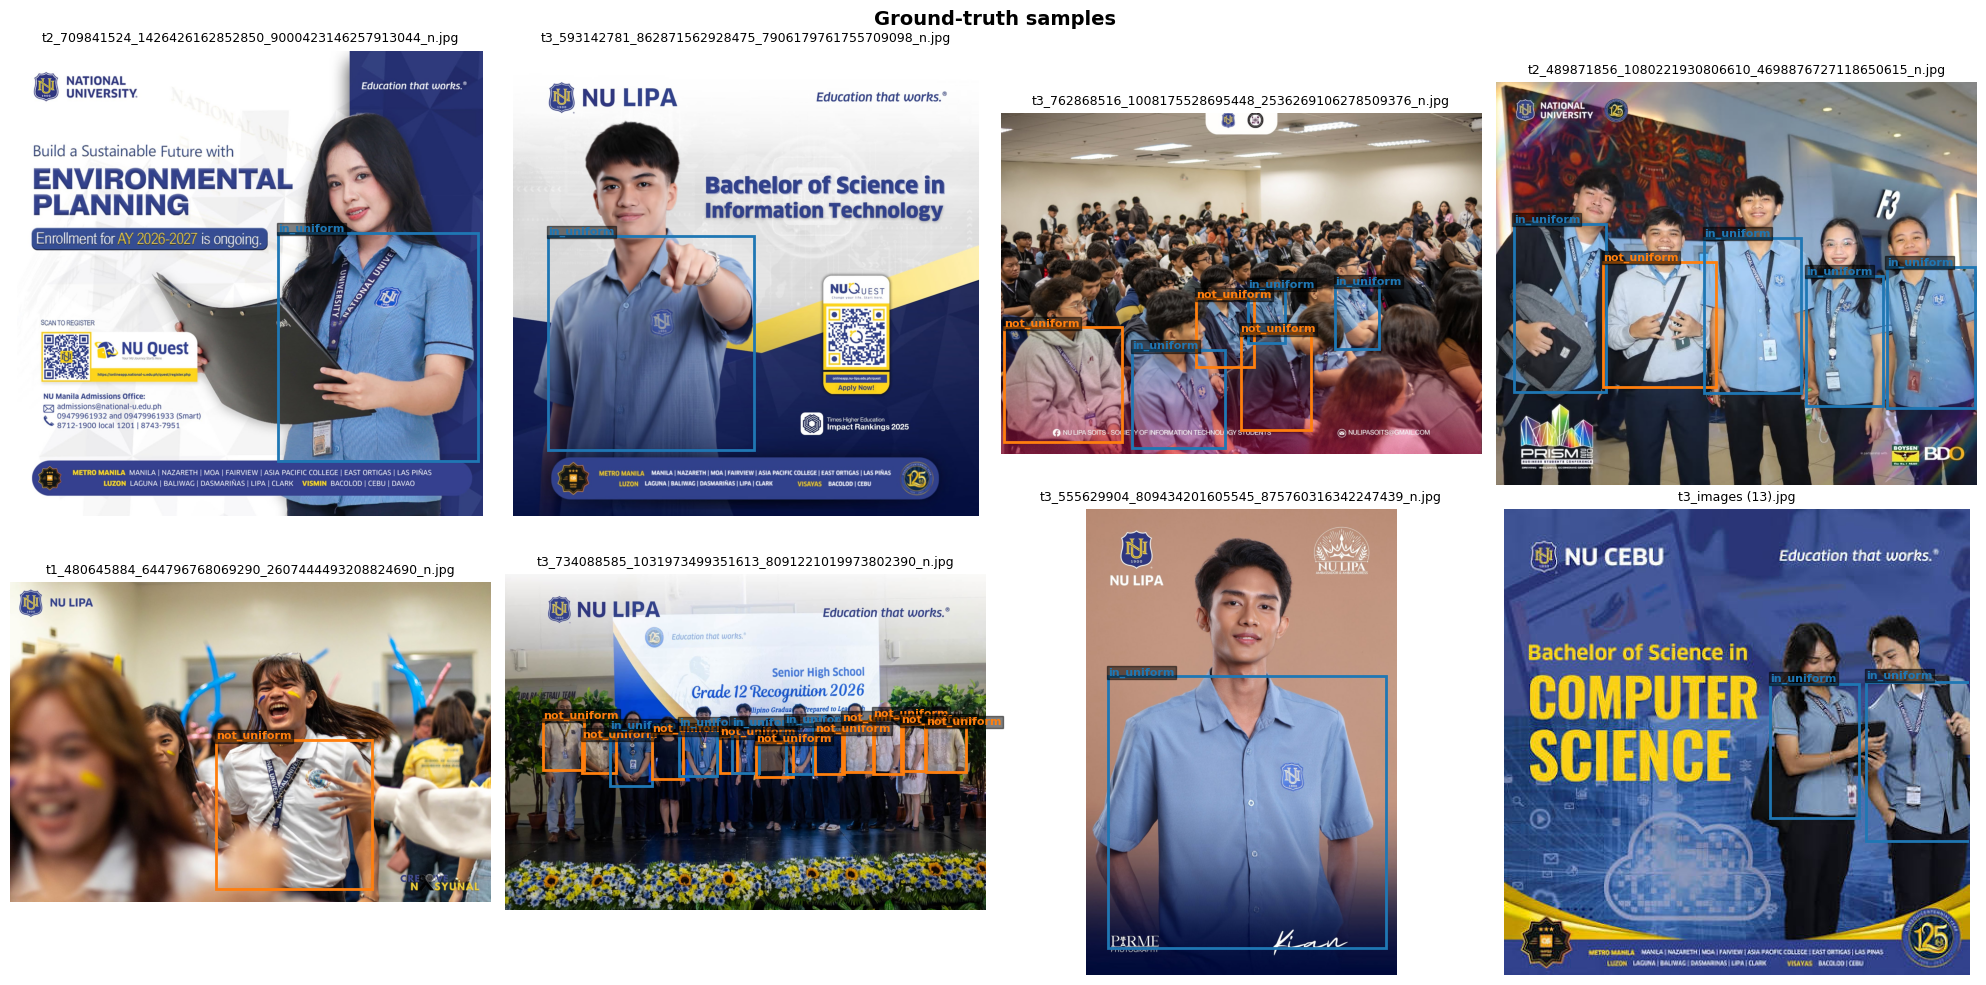

EDA figures saved to /kaggle/working/eda_overview.png and eda_samples.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 2 · EDA (data visualizations)
# ══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# ---- Collect annotation statistics from the training split ----
records = []
for img_path in splits['train']:
    lbl = label_for(img_path)
    if not lbl.exists():
        continue
    for line in lbl.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        c = int(parts[0])
        cx, cy, w, h = map(float, parts[1:5])
        records.append({'class': c, 'cx': cx, 'cy': cy, 'w': w, 'h': h})
df = pd.DataFrame(records)
assert not df.empty, 'No annotations parsed - check label files are YOLO format'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EDA - unidataset (train split)', fontsize=16, fontweight='bold')

# (a) Images per split
ax = axes[0, 0]
counts = {s: len(v) if v else 0 for s, v in splits.items()}
ax.bar(counts.keys(), counts.values(), color=['#3584e4', '#33d17a', '#e5a50a'])
for i, (s, c) in enumerate(counts.items()):
    ax.text(i, c + max(counts.values()) * 0.01, str(c), ha='center', fontweight='bold')
ax.set_title('Images per split'); ax.set_ylabel('count')

# (b) Class distribution
ax = axes[0, 1]
cls_counts = df['class'].value_counts().sort_index()
names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f'class_{i}' for i in cls_counts.index]
ax.bar(names, cls_counts.values, color='#e01b24')
for i, v in enumerate(cls_counts.values):
    ax.text(i, v + cls_counts.max() * 0.01, str(v), ha='center', fontweight='bold')
ax.set_title('Instances per class'); ax.set_ylabel('count')
if len(names) > 6:
    ax.tick_params(axis='x', rotation=45)

# (c) Bounding box width/height distribution
ax = axes[1, 0]
ax.hist(df['w'], bins=50, alpha=0.6, label='width', color='#3584e4')
ax.hist(df['h'], bins=50, alpha=0.6, label='height', color='#33d17a')
ax.set_title('BBox size distribution (normalized)'); ax.set_xlabel('size'); ax.legend()

# (d) Box center positions
ax = axes[1, 1]
ax.scatter(df['cx'], df['cy'], s=3, alpha=0.3, color='#813d9c')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.invert_yaxis()
ax.set_title('BBox center positions'); ax.set_xlabel('cx'); ax.set_ylabel('cy')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Extra stats ----
print('--- Bounding box statistics (normalized) ---')
print(df[['w', 'h']].describe().round(4).to_string())
df['aspect'] = df['w'] / df['h'].clip(lower=1e-6)
print(f"\nAspect ratio  min={df['aspect'].min():.2f}  median={df['aspect'].median():.2f}  max={df['aspect'].max():.2f}")
print(f"Class balance ratio max/min = {cls_counts.max() / max(cls_counts.min(), 1):.2f}")

# ---- Visualize sample images with ground-truth boxes ----
CMAP = plt.get_cmap('tab10')
sample = random.sample(splits['train'], min(8, len(splits['train'])))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, img_path in zip(axes.flat, sample):
    img = np.array(Image.open(img_path).convert('RGB'))
    H, W = img.shape[:2]
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=9)
    lbl = label_for(img_path)
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            parts = line.split()
            c = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])
            x1, y1 = (cx - w / 2) * W, (cy - h / 2) * H
            name = CLASS_NAMES[c] if c < len(CLASS_NAMES) else f'class_{c}'
            ax.add_patch(patches.Rectangle((x1, y1), w * W, h * H,
                         linewidth=2, edgecolor=CMAP(c % 10), facecolor='none'))
            ax.text(x1, y1 - 3, name, color=CMAP(c % 10), fontsize=8,
                    fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.axis('off')
plt.suptitle('Ground-truth samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA figures saved to /kaggle/working/eda_overview.png and eda_samples.png')

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 2b · DATASET AUDIT (labels sanity + leakage)
# ══════════════════════════════════════════════════════════════════════════
import hashlib
from collections import defaultdict, Counter

issues = defaultdict(list)
hash_index = defaultdict(list)
per_split_cls = {}

for split, imgs in splits.items():
    if not imgs:
        continue
    cls_ct = Counter()
    for p in imgs:
        hash_index[hashlib.md5(p.read_bytes()).hexdigest()].append((split, p.name))
        lbl = label_for(p)
        if not lbl.exists():
            issues['missing label file'].append(f'{split}/{p.name}')
            continue
        txt = lbl.read_text().strip()
        if not txt:
            issues['empty label (treated as background)'].append(f'{split}/{p.name}')
            continue
        seen = set()
        for ln in txt.splitlines():
            parts = ln.split()
            if len(parts) != 5:
                issues['bad line format (not 5 columns - polygon/segment labels?)'].append(f'{split}/{lbl.name}')
                continue
            try:
                c = int(float(parts[0])); cx, cy, w, h = map(float, parts[1:])
            except ValueError:
                issues['non-numeric values'].append(f'{split}/{lbl.name}')
                continue
            if not (0 <= c < NC):
                issues[f'class id outside 0..{NC-1}'].append(f'{split}/{lbl.name}')
            if not all(0.0 <= v <= 1.0 for v in (cx, cy, w, h)):
                issues['coords outside [0,1] (not normalized?)'].append(f'{split}/{lbl.name}')
            if w <= 0 or h <= 0:
                issues['zero-size box'].append(f'{split}/{lbl.name}')
            key = (c, round(cx, 4), round(cy, 4), round(w, 4), round(h, 4))
            if key in seen:
                issues['duplicate box in same image'].append(f'{split}/{lbl.name}')
            seen.add(key)
            cls_ct[c] += 1
    per_split_cls[split] = cls_ct

leaks = [v for v in hash_index.values() if len({s for s, _ in v}) > 1]
if leaks:
    issues['IDENTICAL image in multiple splits (LEAKAGE)'] = [f'{s}/{n}' for grp in leaks for s, n in grp]

print(' Per-split class counts (check val/test look like train):')
for s, ct in per_split_cls.items():
    tot = sum(ct.values()) or 1
    row = '  '.join(f'{(CLASS_NAMES[c] if c < len(CLASS_NAMES) else c)}={ct[c]} ({ct[c]/tot:.0%})' for c in sorted(ct))
    print(f'   {s:>5}: {row}')

print()
if not issues:
    print('Audit clean: no label problems, no exact-duplicate leakage.')
else:
    for k, v in issues.items():
        print(f'  {k}: {len(v)}  e.g. {v[:3]}')
critical = [k for k in issues if k.startswith(('class id', 'coords', 'zero-size', 'non-numeric', 'bad line', 'IDENTICAL'))]
print('\n Fix the critical items above before training.' if critical else '\n➡️  No critical issues - safe to train.')
print('  Hashing only catches EXACT duplicates. If the images are video frames of the same scene/person, '
      'near-duplicates can still straddle train/val/test and make scores optimistic.')

 Per-split class counts (check val/test look like train):
   train: in_uniform=916 (46%)  not_uniform=1067 (54%)
     val: in_uniform=108 (44%)  not_uniform=140 (56%)
    test: in_uniform=211 (47%)  not_uniform=237 (53%)

  duplicate box in same image: 8  e.g. ['train/t1_481082859_644222428126724_1588288320828410444_n.txt', 'train/t1_481082859_644222428126724_1588288320828410444_n.txt', 'train/t2_487468742_1070677408427729_884050131361926115_n.txt']
  IDENTICAL image in multiple splits (LEAKAGE): 6  e.g. ['train/t3_749354499_1044617811420515_8893957874417817354_n.jpg', 'test/t2_749354499_1044617811420515_8893957874417817354_n.jpg', 'train/t3_828572948_1424557146298823_5570346636502134535_n.jpg']

 Fix the critical items above before training.
  Hashing only catches EXACT duplicates. If the images are video frames of the same scene/person, near-duplicates can still straddle train/val/test and make scores optimistic.


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 3 · TRAINING CONFIG  (shared args + per-stage overrides)
# ══════════════════════════════════════════════════════════════════════════
import torch

MODEL_WEIGHTS = 'yolo11l.pt'    # n = fastest, s = good default for ~400 imgs, m = more capacity (risk of overfit)

# ---- Shared by both stages ----
CONFIG = {
    'data'        : str(FIXED_YAML),
    'imgsz'       : 763,
    'batch'       : 16,                 # drop to 8 on CUDA OOM
    'device'      : '0' if torch.cuda.is_available() else 'cpu',
    'workers'     : 4,                  # Kaggle gives 4 CPUs; the default 8 just oversubscribes
    'cache'       : 'ram',              # dataset is tiny -> decode once, train faster
    'amp'         : True,               # mixed precision on T4
    'seed'        : 42, 'deterministic': True,
    # optimiser / schedule
    'optimizer'   : 'AdamW',
    'cos_lr'      : True,               # cosine decay instead of linear
    'momentum'    : 0.937,
    'weight_decay': 0.0005,
    # augmentation: 
    'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
    'degrees': 5.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0,
    'fliplr': 0.5, 'flipud': 0.0,
    'mosaic': 1.0, 'mixup': 0.1,
    # bookkeeping
    'project'     : '/kaggle/working/runs',
    'plots'       : True, 'verbose': True,
    'save_period' : -1,
}

# ---- Stage 1: frozen backbone, train neck+head only ----
STAGE1 = {
    'name': 'stage1_frozen_head',
    'epochs': 100,
    'freeze': 10,              # YOLOv8: layers 0-9 = backbone
    'lr0': 2e-3, 'lrf': 0.1,   # higher LR is safe: only head weights move
    'warmup_epochs': 100, 'warmup_bias_lr': 0.01,
    'patience': 10,             # no early stop - short fixed warm-up
    'close_mosaic': 0,
}

# ---- Stage 2: unfreeze all, gentle fine-tune ----
STAGE2 = {
    'name': 'stage2_full_finetune',
    'epochs': 500,
    'lr0': 5e-4, 'lrf': 0.01,  # ~4x lower than stage 1 to protect pretrained features
    'warmup_epochs': 1, 'warmup_bias_lr': 0.0,
    'patience': 25,            # early stopping on val fitness
    'close_mosaic': 10,        # last 10 epochs without mosaic -> matches real image statistics
}

print('  Compute:')
print(f'   PyTorch     : {torch.__version__}  | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU         : {torch.cuda.get_device_name(0)}  ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)')
print(f'\n  Model: {MODEL_WEIGHTS}   data: {CONFIG["data"]}')
for nm, st in (('STAGE 1', STAGE1), ('STAGE 2', STAGE2)):
    print(f'\n{nm}: ' + ', '.join(f'{k}={v}' for k, v in st.items()))

  Compute:
   PyTorch     : 2.11.0+cu128  | CUDA: True
   GPU         : Tesla T4  (15.6 GB)

  Model: yolo11l.pt   data: /kaggle/working/data_fixed.yaml

STAGE 1: name=stage1_frozen_head, epochs=100, freeze=10, lr0=0.002, lrf=0.1, warmup_epochs=100, warmup_bias_lr=0.01, patience=10, close_mosaic=0

STAGE 2: name=stage2_full_finetune, epochs=500, lr0=0.0005, lrf=0.01, warmup_epochs=1, warmup_bias_lr=0.0, patience=25, close_mosaic=10


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 4 · TWO-STAGE TRAINING (frozen head -> full fine-tune)
# ══════════════════════════════════════════════════════════════════════════
!pip install -q ultralytics
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

def run_stage(weights, stage_cfg):
    """Train one stage; return (best.pt path, run dir)."""
    m = YOLO(weights)
    m.train(**{**CONFIG, **stage_cfg})
    return Path(m.trainer.best), Path(m.trainer.save_dir)   # trainer.* is robust to auto-renamed run folders

def val_fitness(ckpt):
    """mAP50-95 on the VALIDATION split (used only for picking between stages)."""
    r = YOLO(str(ckpt)).val(data=CONFIG['data'], split='val', imgsz=CONFIG['imgsz'], batch=CONFIG['batch'],
                            device=CONFIG['device'], plots=False, verbose=False)
    return float(r.box.map), float(r.box.map50)

print('═' * 70, '\n STAGE 1 - frozen backbone, training head only\n' + '═' * 70)
best1, dir1 = run_stage(MODEL_WEIGHTS, STAGE1)

print('═' * 70, '\n STAGE 2 - unfreeze all layers, full fine-tune\n' + '═' * 70)
best2, dir2 = run_stage(str(best1), STAGE2)

# ---- Keep whichever stage generalises better on VAL (guards against stage 2 overfitting) ----
(m1_5095, m1_50), (m2_5095, m2_50) = val_fitness(best1), val_fitness(best2)
print(f'\n Val mAP50-95  stage1={m1_5095:.4f} (mAP50 {m1_50:.4f})   stage2={m2_5095:.4f} (mAP50 {m2_50:.4f})')
best_ckpt, best_dir = (best2, dir2) if m2_5095 >= m1_5095 else (best1, dir1)
print(f' Best checkpoint: {best_ckpt}   (from {"stage 2" if best_ckpt == best2 else "stage 1"})')

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7087.0/8156.9 GB disk)
══════════════════════════════════════════════════════════════════════ 
 STAGE 1 - frozen backbone, training head only
══════════════════════════════════════════════════════════════════════
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, fli

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100      6.46G      1.384       1.47      1.463        155        768: 100% ━━━━━━━━━━━━ 24/24 2.0it/s 11.8s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s2.2s
                   all         50        248      0.623      0.748      0.721       0.43

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      6.46G      1.323      1.114      1.404         87        768: 100% ━━━━━━━━━━━━ 24/24 2.0it/s 12.2s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s2.2s
                   all         50        248      0.693       0.72      0.771      0.484

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      6.46G      1.306     0.9854      1.379        120        768: 100% ━━━━━━━━━━━━ 24/24 1.9it/s 13.0s0.5s
                 Class     Images  Instance

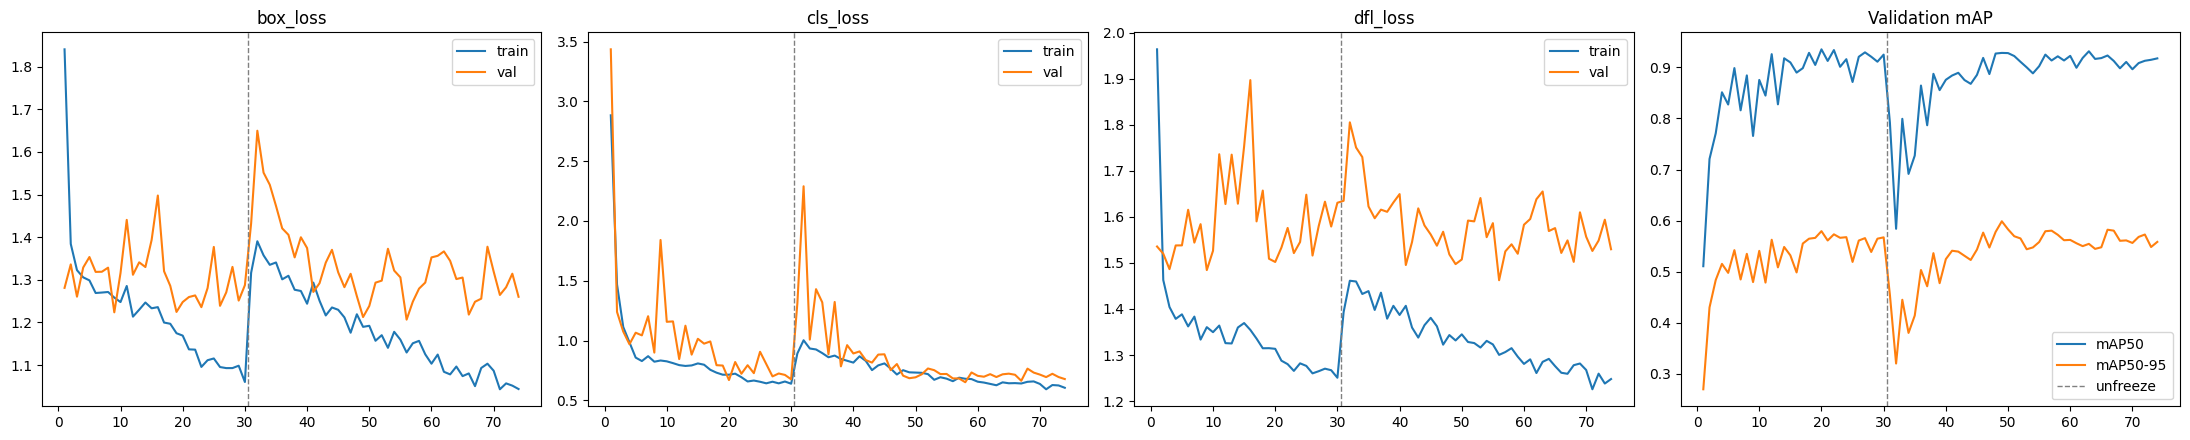

Final val-train box_loss gap: +0.216  (a large positive gap that keeps growing = overfitting -> smaller model, stronger aug, or fewer epochs)


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 4b · LEARNING CURVES (overfitting check)
# ══════════════════════════════════════════════════════════════════════════
def load_results(run_dir):
    df = pd.read_csv(Path(run_dir) / 'results.csv')
    df.columns = df.columns.str.strip()
    return df

d1, d2 = load_results(dir1), load_results(dir2)
d2 = d2.assign(epoch=d2['epoch'] + len(d1))          # continue the x-axis after stage 1
full = pd.concat([d1, d2], ignore_index=True)
switch = len(d1) + 0.5

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, loss in zip(axes[:3], ['box_loss', 'cls_loss', 'dfl_loss']):
    if f'train/{loss}' in full:
        ax.plot(full['epoch'], full[f'train/{loss}'], label='train')
        ax.plot(full['epoch'], full[f'val/{loss}'], label='val')
    ax.axvline(switch, color='gray', ls='--', lw=1); ax.set_title(loss); ax.legend()
ax = axes[3]
for col, lab in [('metrics/mAP50(B)', 'mAP50'), ('metrics/mAP50-95(B)', 'mAP50-95')]:
    if col in full:
        ax.plot(full['epoch'], full[col], label=lab)
ax.axvline(switch, color='gray', ls='--', lw=1, label='unfreeze')
ax.set_title('Validation mAP'); ax.legend()
plt.tight_layout(); plt.savefig('/kaggle/working/learning_curves.png', dpi=120, bbox_inches='tight'); plt.show()

gap = full['val/box_loss'].iloc[-1] - full['train/box_loss'].iloc[-1] if 'val/box_loss' in full else float('nan')
print(f'Final val-train box_loss gap: {gap:+.3f}  (a large positive gap that keeps growing = overfitting -> '
      'smaller model, stronger aug, or fewer epochs)')

Evaluating on split: test
WARNING ⚠️ imgsz=[763] must be multiple of max stride 32, updating to [768]
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11l summary (fused): 190 layers, 25,280,854 parameters, 0 gradients, 86.8 GFLOPs
val: Fast image access ✅ (ping: 1.0±1.1 ms, read: 344.5±144.3 MB/s, size: 234.8 KB)
val: Scanning /kaggle/input/datasets/plantpog/w43453ert/unidataset/labels/test... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 910.8it/s 0.1s
val: /kaggle/input/datasets/plantpog/w43453ert/unidataset/images/test/t2_710280216_1422538633241603_5628094528244541024_n.jpg: 2 duplicate labels removed
val: /kaggle/input/datasets/plantpog/w43453ert/unidataset/images/test/t2_712026865_1427389612756505_1671944981525474629_n.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/plantpog/w43453ert/unidataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box

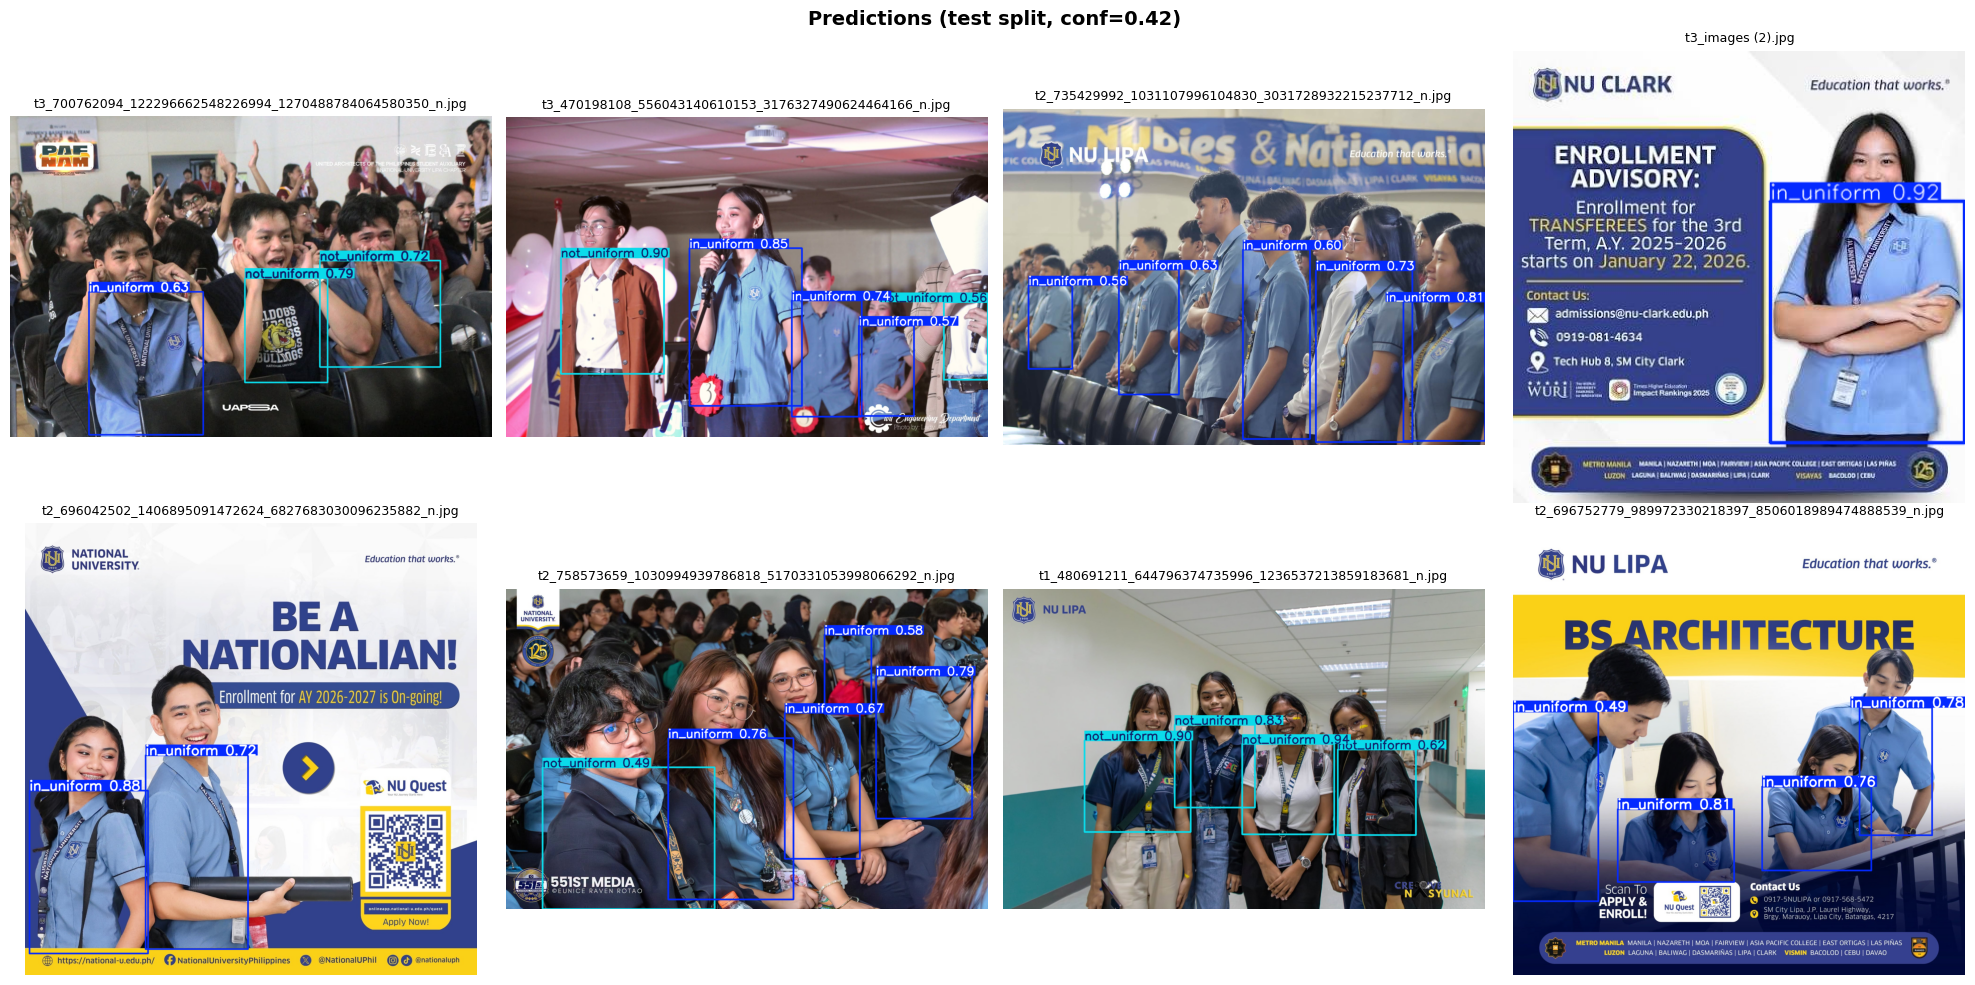

Prediction grid saved to /kaggle/working/test_predictions.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 5 · TESTING ON THE TEST SET (run once - never tune on this)
# ══════════════════════════════════════════════════════════════════════════
model = YOLO(str(best_ckpt))

eval_split = 'test' if splits.get('test') else 'val'
print(f'Evaluating on split: {eval_split}')

test_metrics = model.val(data=CONFIG['data'], split=eval_split, imgsz=CONFIG['imgsz'],
                         batch=CONFIG['batch'], device=CONFIG['device'], plots=True)

print('\n Overall metrics:')
print(f'   Precision    : {test_metrics.box.mp:.4f}')
print(f'   Recall       : {test_metrics.box.mr:.4f}')
print(f'   mAP@0.5      : {test_metrics.box.map50:.4f}')
print(f'   mAP@0.5:0.95 : {test_metrics.box.map:.4f}')

# ---- Per-class breakdown (a good mean can hide one weak class) ----
print('\n📊 Per-class mAP@0.5:0.95:')
for idx, ap in zip(test_metrics.box.ap_class_index, test_metrics.box.maps[test_metrics.box.ap_class_index]):
    print(f'   {model.names[int(idx)]:<14}: {ap:.4f}')

# ---- Pick a deployment confidence threshold from the F1-vs-confidence curve ----
try:
    f1_mean = np.asarray(test_metrics.box.f1_curve).mean(0)
    conf_best = float(np.asarray(test_metrics.box.px)[f1_mean.argmax()])
    print(f'\n F1-optimal confidence threshold: {conf_best:.2f}  (F1={f1_mean.max():.3f})')
except Exception as e:
    conf_best = 0.25
    print(f'\n(could not read F1 curve: {e}) - using conf=0.25')

# ---- Does test-time augmentation help? ----
tta = model.val(data=CONFIG['data'], split=eval_split, imgsz=CONFIG['imgsz'], batch=CONFIG['batch'],
                device=CONFIG['device'], augment=True, plots=False, verbose=False)
print(f' TTA (augment=True): mAP50-95 {tta.box.map:.4f}  vs  plain {test_metrics.box.map:.4f}  '
      f'-> {"use TTA at inference" if tta.box.map > test_metrics.box.map else "TTA not worth the extra latency"}')

# ---- Visualize predictions ----
sample_src = splits['test'] if splits.get('test') else splits['val']
sample = random.sample(sample_src, min(8, len(sample_src)))
preds = model.predict(sample, imgsz=CONFIG['imgsz'], device=CONFIG['device'], conf=conf_best, verbose=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, pred in zip(axes.flat, preds):
    ax.imshow(pred.plot()[..., ::-1])      # pred.plot() returns BGR -> convert to RGB for matplotlib
    ax.set_title(f'{Path(pred.path).name}', fontsize=9)
    ax.axis('off')
plt.suptitle(f'Predictions ({eval_split} split, conf={conf_best:.2f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Prediction grid saved to /kaggle/working/test_predictions.png')

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 6 · MODEL SAVING (YOLO .pt + ONNX)
# ══════════════════════════════════════════════════════════════════════════
OUT_DIR = Path('/kaggle/working/model_export')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- 1. Standard YOLOv8 weights ----
pt_out = OUT_DIR / 'unidataset_yolov8_best.pt'
shutil.copy2(best_ckpt, pt_out)
print(f'YOLOv8 weights → {pt_out} ({pt_out.stat().st_size / 1e6:.1f} MB)')

# ---- 2. ONNX export ----
!pip install -q onnx onnxsim
model = YOLO(str(pt_out))
onnx_path = model.export(format='onnx', imgsz=CONFIG['imgsz'], half=False, simplify=True)
onnx_out = OUT_DIR / Path(onnx_path).name
if Path(onnx_path).resolve() != onnx_out.resolve():
    shutil.move(onnx_path, onnx_out)
print(f'ONNX model    → {onnx_out} ({onnx_out.stat().st_size / 1e6:.1f} MB)')

# ---- 3. Quick ONNX inference sanity check ----
import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_out), providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
inp = sess.get_inputs()[0]
print(f'\n ONNX sanity check: input {inp.shape} {inp.type} | outputs: {[o.name for o in sess.get_outputs()]}')

print('\n Final export directory:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'   {f.name:<35} {f.stat().st_size / 1e6:8.1f} MB')
print('\n Download these files from Kaggle: Output → /kaggle/working/model_export/')

YOLOv8 weights → /kaggle/working/model_export/unidataset_yolov8_best.pt (51.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.1 MB/s eta 0:00:0000:0100:01
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ imgsz=[763] must be multiple of max stride 32, updating to [768]
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11l summary (fused): 190 layers, 25,280,854 parameters, 0 gradients, 125.2 GFLOPs

PyTorch: starting from '/kaggle/working/model_export/unidataset_yolov8_best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 6, 12096) (48.8 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 497ms
Pre

/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(



 ONNX sanity check: input [1, 3, 768, 768] tensor(float) | outputs: ['output0']

 Final export directory:
   unidataset_yolov8_best.onnx            101.6 MB
   unidataset_yolov8_best.pt               51.2 MB

 Download these files from Kaggle: Output → /kaggle/working/model_export/
